In [2]:
from common.paths import get_sber_gitignore_data_dpath, get_sber_data_dpath
from common.logger import JUPYTER_LOGGER as logger

import pandas as pd

import catboost
import lightgbm
import xgboost
from umap import UMAP
import optuna
# CalibratedClassifierCV
from sklearn.calibration import CalibratedClassifierCV

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

In [3]:
features_fpath = get_sber_gitignore_data_dpath() / "features_with_judge_scores.csv"
test_fpath = get_sber_data_dpath() / "knowledge_bench_public.csv"
features_df = pd.read_csv(features_fpath)
test_df = pd.read_csv(test_fpath)
features_df.shape

(1391, 1622)

In [4]:
print(test_df.shape)
test_df.head()

(1044, 5)


,prompt,model_answer,is_hallucination,correct_answer,comment
0,За что Оскар Густав Рейландер был удостоен мед...,Оскар Густав Рейландер был удостоен медали на ...,False,За выставленные фотографии,NaN
1,В каком году рэпер King Von был убит?,Рэпер King Von был убит 6 ноября 2020 года в А...,False,2020,NaN
2,Сколько миллионов рублей было выделено на реал...,На реализацию программы защиты свидетелей в Ро...,True,1318,NaN
3,Какая компания лицензировала на русском языке ...,"Компания ""Кино без границ"" лицензировала на ру...",True,Reanimedia,NaN
4,Кто из британских ревизионистов в 2000 году пр...,В 2000 году британский ревизионист Дэвид Ирвин...,True,Джоэла Хейворда,NaN


In [8]:
import warnings
warnings.filterwarnings("ignore")

target_col = "judge_score"

hooks_columns = [col for col in features_df.columns if col.startswith("feature_")]
other_num_columns = features_df.select_dtypes(include=["number"]).columns.difference(hooks_columns)
str_columns = features_df.select_dtypes(include=["object"]).columns.difference([target_col])

other_num_columns = other_num_columns.difference(["sample_id", "is_hallucination", "hallucination_score"])

logger.info(f"Кол-во признаков-хуков: {len(hooks_columns)}")
logger.info(f"Кол-во числовых признаков: {len(other_num_columns)}")
logger.info(f"Кол-во строковых признаков: {len(str_columns)}")

print(other_num_columns)
print(str_columns)

2026-04-01 19:33:40,822 - jupyter-notebooks - INFO - [JUPYTER 📓] Кол-во признаков-хуков: 1613
2026-04-01 19:33:40,824 - jupyter-notebooks - INFO - [JUPYTER 📓] Кол-во числовых признаков: 5
2026-04-01 19:33:40,825 - jupyter-notebooks - INFO - [JUPYTER 📓] Кол-во строковых признаков: 4


Index(['answer_gt_ratio', 'ground_truth_length', 'model_answer_length',
       'query_length', 'temperature'],
      dtype='str')
Index(['ground_truth', 'judge_prompt', 'model_answer', 'query'], dtype='str')


In [9]:
# count correlations between hallucination_score and target
if "hallucination_score" in features_df.columns:
    corr = features_df[["hallucination_score", target_col]].corr().iloc[0, 1]
    logger.info(f"Корреляция между hallucination_score и {target_col}: {corr:.4f}")

2026-04-01 19:33:57,348 - jupyter-notebooks - INFO - [JUPYTER 📓] Корреляция между hallucination_score и judge_score: -0.6184


In [10]:
# basic str stats

features_df["query_length"] = features_df["query"].str.len()
features_df["model_answer_length"] = features_df["model_answer"].str.len()
features_df["ground_truth_length"] = features_df["ground_truth"].str.len()

features_df["answer_gt_ratio"] = features_df["model_answer_length"] / (features_df["ground_truth_length"] + 1e-5)

other_num_columns = other_num_columns.union({"answer_gt_ratio", "model_answer_length", "ground_truth_length"})

In [11]:
# repetition score
def repetition_score(text):
    tokens = text.split()
    if len(tokens) == 0:
        return 0.0
    unique_tokens = set(tokens)
    return 1 - len(unique_tokens) / len(tokens)

# token rank
def token_rank(text):
    tokens = text.split()
    if len(tokens) == 0:
        return 0.0
    token_counts = pd.Series(tokens).value_counts()
    most_common_count = token_counts.iloc[0]
    return most_common_count / len(tokens)

features_df["model_answer_repetition_score"] = features_df["model_answer"].apply(repetition_score)
features_df["model_answer_token_rank"] = features_df["model_answer"].apply(token_rank)

other_num_columns = other_num_columns.union({"model_answer_repetition_score", "model_answer_token_rank"})

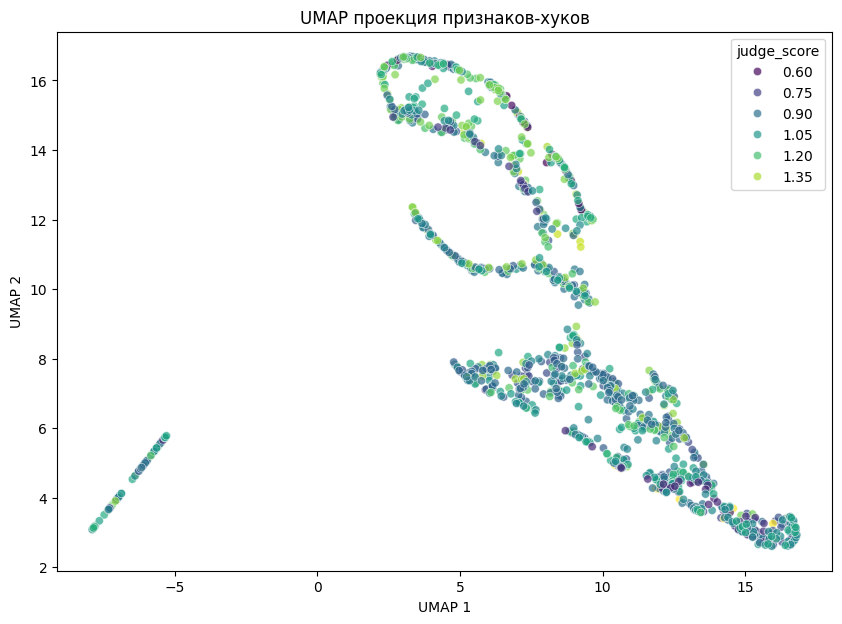

In [12]:
graphic_pca = UMAP(n_components=2, random_state=42)
points = graphic_pca.fit_transform(features_df[hooks_columns])

plt.figure(figsize=(10, 7))
sns.scatterplot(x=points[:, 0], y=points[:, 1], hue=features_df["temperature"], palette="viridis", alpha=0.7)
plt.title("UMAP проекция признаков-хуков")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title=target_col)
plt.show()

In [10]:
n_components = 16

train_pca = PCA(n_components=n_components, random_state=42)

training_points = train_pca.fit_transform(features_df[hooks_columns])
pca_columns = [f"pca_{i}" for i in range(n_components)]
features_df[pca_columns] = training_points

2026-04-01 19:34:20,571 - jupyter-notebooks - INFO - [JUPYTER 📓] X columns: ['answer_gt_ratio', 'ground_truth_length', 'model_answer_length', 'model_answer_repetition_score', 'model_answer_token_rank', 'query_length', 'temperature', 'feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'featur

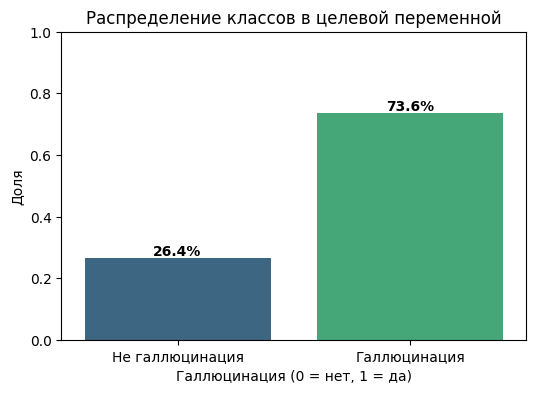

In [13]:
features_df[target_col] = features_df[target_col].fillna(features_df[target_col].mode()[0])
target = features_df[target_col].astype(int)

scaler = StandardScaler()
train_columns = other_num_columns.to_list() + hooks_columns
#.union(set(pca_columns))
features_df[train_columns] = scaler.fit_transform(features_df[train_columns])

X = features_df[train_columns]
y = target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

logger.info(
    f"X columns: {X.columns.tolist()}\n"
)

target_dist = y.value_counts(normalize=True)
plt.figure(figsize=(6, 4))
sns.barplot(x=target_dist.index, y=target_dist.values, palette="viridis")
plt.title("Распределение классов в целевой переменной")
plt.xlabel("Галлюцинация (0 = нет, 1 = да)")
plt.ylabel("Доля")
plt.xticks([0, 1], ["Не галлюцинация", "Галлюцинация"])
plt.ylim(0, 1)
for i, v in enumerate(target_dist.values[::-1]):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
plt.show()

In [15]:
# oversampling

smote = SMOTE()

X, y = smote.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y.value_counts()

judge_score
1    1024
0    1024
Name: count, dtype: int64

In [16]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

def objective(trial):
    model_type = trial.suggest_categorical("model_type", ["catboost", "lightgbm", "xgboost"])
    if model_type == "catboost":
        params = {
            "iterations": trial.suggest_int("iterations", 100, 1000),
            "depth": trial.suggest_int("depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
            "random_seed": 42,
            "verbose": False,
             "auto_class_weights": "Balanced",
        }
        model = catboost.CatBoostClassifier(**params)

    elif model_type == "lightgbm":
        params = {
            "num_leaves": trial.suggest_int("num_leaves", 20, 150),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "random_state": 42,
             "class_weight": "balanced",
        }
        model = lightgbm.LGBMClassifier(**params, verbose=-1)


    else:  # xgboost
        params = {
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "random_state": 42,
            "scale_pos_weight": (y == 1).sum() / (y == 0).sum(),
        }
        model = xgboost.XGBClassifier(**params)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_val_probs = model.predict_proba(X_val)[:, 0]
        score = average_precision_score(y_val, y_val_probs)
        scores.append(score)

    return np.mean(scores)

In [ ]:
study = optuna.create_study(direction="maximize", study_name="model_selection")
study.optimize(objective, n_trials=50)

[I 2026-04-01 19:36:29,052] A new study created in memory with name: model_selection


In [10]:
# best trial
best_trial = study.best_trial
logger.info(f"Лучший результат: {best_trial.value:.4f}")
logger.info("Лучшие параметры:")
for key, value in best_trial.params.items():
    logger.info(f"  {key}: {value}")

2026-04-01 12:56:49,925 - jupyter-notebooks - INFO - [JUPYTER 📓] Лучший результат: 0.8382
2026-04-01 12:56:49,927 - jupyter-notebooks - INFO - [JUPYTER 📓] Лучшие параметры:
2026-04-01 12:56:49,928 - jupyter-notebooks - INFO - [JUPYTER 📓]   model_type: xgboost
2026-04-01 12:56:49,928 - jupyter-notebooks - INFO - [JUPYTER 📓]   max_depth: 7
2026-04-01 12:56:49,928 - jupyter-notebooks - INFO - [JUPYTER 📓]   learning_rate: 0.06991102397915394
2026-04-01 12:56:49,932 - jupyter-notebooks - INFO - [JUPYTER 📓]   n_estimators: 762


In [11]:
best_trial = study.best_trial
best_model_type = best_trial.params["model_type"]
if best_model_type == "catboost":
    best_model = catboost.CatBoostClassifier(
        iterations=best_trial.params["iterations"],
        depth=best_trial.params["depth"],
        learning_rate=best_trial.params["learning_rate"],
        random_seed=42,
        verbose=False,
    )
elif best_model_type == "lightgbm":
    best_model = lightgbm.LGBMClassifier(
        num_leaves=best_trial.params["num_leaves"],
        learning_rate=best_trial.params["learning_rate"],
        n_estimators=best_trial.params["n_estimators"],
        random_state=42,
    )
else:  # xgboost
    best_model = xgboost.XGBClassifier(
        max_depth=best_trial.params["max_depth"],
        learning_rate=best_trial.params["learning_rate"],
        n_estimators=best_trial.params["n_estimators"],
        random_state=42,
    )
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

logger.info(f"Classification Report:\n{report}")
logger.info(f"Confusion Matrix:\n{conf_matrix}")
logger.info(f"F1 Score: {f1:.4f}")

2026-04-01 12:57:36,749 - jupyter-notebooks - INFO - [JUPYTER 📓] Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.18      0.28        74
           1       0.77      0.98      0.86       205

    accuracy                           0.76       279
   macro avg       0.74      0.58      0.57       279
weighted avg       0.75      0.76      0.71       279

2026-04-01 12:57:36,751 - jupyter-notebooks - INFO - [JUPYTER 📓] Confusion Matrix:
[[ 13  61]
 [  5 200]]
2026-04-01 12:57:36,753 - jupyter-notebooks - INFO - [JUPYTER 📓] F1 Score: 0.8584


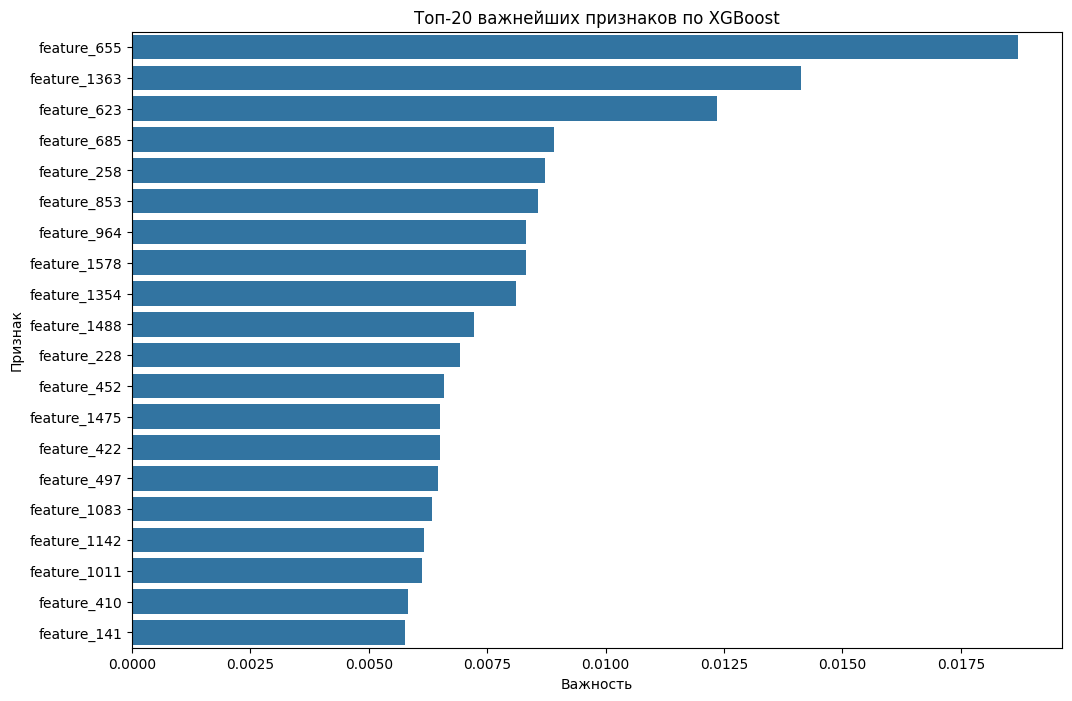

In [12]:
# best_model - catboost, feature importance
if best_model_type == "catboost":
    feature_importances = best_model.get_feature_importance()
    feature_names = X.columns
    importance_df = pd.DataFrame({"feature": feature_names, "importance": feature_importances})
    importance_df = importance_df.sort_values(by="importance", ascending=False)
    plt.figure(figsize=(12, 8))
    sns.barplot(x="importance", y="feature", data=importance_df.head(20))
    plt.title("Топ-20 важнейших признаков по CatBoost")
    plt.xlabel("Важность")
    plt.ylabel("Признак")
    plt.show()

# xgb feature importance
elif best_model_type == "xgboost":
    feature_importances = best_model.feature_importances_
    feature_names = X.columns
    importance_df = pd.DataFrame({"feature": feature_names, "importance": feature_importances})
    importance_df = importance_df.sort_values(by="importance", ascending=False)
    plt.figure(figsize=(12, 8))
    sns.barplot(x="importance", y="feature", data=importance_df.head(20))
    plt.title("Топ-20 важнейших признаков по XGBoost")
    plt.xlabel("Важность")
    plt.ylabel("Признак")
    plt.show()

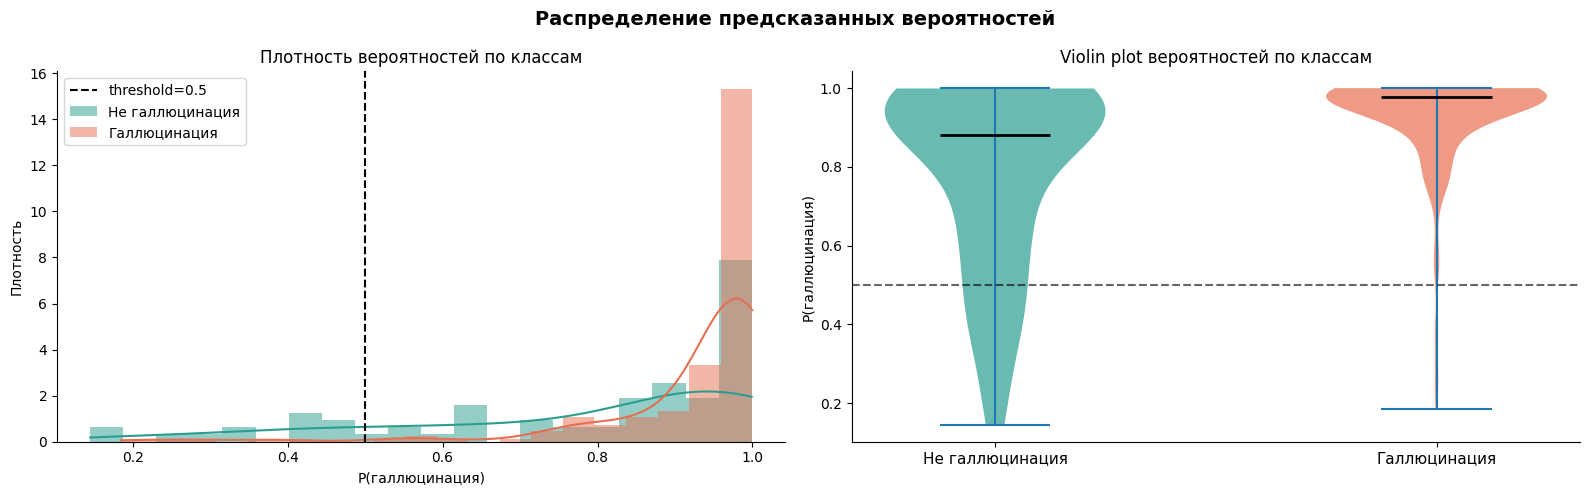

In [13]:
y_probs = best_model.predict_proba(X_test)[:, 1]

df_proba = pd.DataFrame({"proba": y_probs, "target": y_test.values})
colors = {0: "#2a9d8f", 1: "#e76f51"}
labels = {0: "Не галлюцинация", 1: "Галлюцинация"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Распределение предсказанных вероятностей", fontsize=14, fontweight="bold")

# гистограмма с KDE
for label in [0, 1]:
    subset = df_proba[df_proba["target"] == label]["proba"]
    sns.histplot(
        subset, bins=20, kde=True, ax=axes[0],
        color=colors[label], alpha=0.5, label=labels[label],
        stat="density", linewidth=0,
    )
    axes[0].lines[-1].set_color(colors[label])

axes[0].axvline(0.5, color="black", linestyle="--", lw=1.5, label="threshold=0.5")
axes[0].set_title("Плотность вероятностей по классам")
axes[0].set_xlabel("P(галлюцинация)")
axes[0].set_ylabel("Плотность")
axes[0].legend(fontsize=10)
sns.despine(ax=axes[0])

# violin plot
df_proba["Класс"] = df_proba["target"].map(labels)
parts = axes[1].violinplot(
    [df_proba[df_proba["target"] == 0]["proba"],
     df_proba[df_proba["target"] == 1]["proba"]],
    positions=[0, 1], showmedians=True, showextrema=True,
)
for i, (pc, color) in enumerate(zip(parts["bodies"], [colors[0], colors[1]])):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(list(labels.values()), fontsize=11)
axes[1].set_title("Violin plot вероятностей по классам")
axes[1].set_ylabel("P(галлюцинация)")
axes[1].axhline(0.5, color="black", linestyle="--", lw=1.5, alpha=0.6)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

In [14]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

test_df = features_df.iloc[X_test.index].copy()
test_df["pred_proba"] = y_probs
test_df["pred_label"] = (y_probs >= 0.5).astype(int)
test_df["error_type"] = "Верно"
test_df.loc[(test_df["pred_label"] == 1) & (test_df[target_col] == 0), "error_type"] = "FP"
test_df.loc[(test_df["pred_label"] == 0) & (test_df[target_col] == 1), "error_type"] = "FN"
errors_df = test_df[test_df["error_type"] != "Верно"]

logger.info(f"Ошибок: {len(errors_df)} из {len(test_df)} ({len(errors_df)/len(test_df)*100:.1f}%)")
logger.info(f"FP: {(test_df['error_type']=='FP').sum()} | FN: {(test_df['error_type']=='FN').sum()}")

color_map = {"Верно": "#2a9d8f", "FP": "#e76f51", "FN": "#f4a261"}

# ── 1a. Pie ──────────────────────────────────────────────────────
type_counts = test_df["error_type"].value_counts()
fig_pie = go.Figure(go.Pie(
    labels=type_counts.index.tolist(),
    values=type_counts.values.tolist(),
    marker_colors=[color_map[k] for k in type_counts.index],
    hole=0.35,
    textinfo="label+percent+value",
))
fig_pie.update_layout(title_text="Типы предсказаний", height=400)
fig_pie.show()

# ── 2. Scatter: pred_proba vs hallucination_score ──────────────────
if "hallucination_score" in test_df.columns:
    hover_cols = ["query", "ground_truth", "model_answer", "pred_proba", "error_type"]
    hover_cols = [c for c in hover_cols if c in test_df.columns]

    fig2 = px.scatter(
        test_df,
        x="hallucination_score",
        y="pred_proba",
        color="error_type",
        color_discrete_map=color_map,
        symbol="error_type",
        symbol_map={"Верно": "circle", "FP": "x", "FN": "triangle-up"},
        hover_data={c: True for c in hover_cols},
        title="pred_proba vs hallucination_score",
        labels={"hallucination_score": "hallucination_score (fuzz)", "pred_proba": "P(галлюцинация)"},
        opacity=0.75,
        height=520,
    )
    fig2.add_hline(y=0.5, line_dash="dash", line_color="black", opacity=0.5)
    fig2.update_traces(marker_size=9)
    fig2.update_layout(legend_title_text="Тип предсказания")
    fig2.show()

# ── 3. Box: hallucination_score по типам ──────────────────────────
if "hallucination_score" in test_df.columns:
    fig3 = px.box(
        test_df,
        x="error_type",
        y="hallucination_score",
        color="error_type",
        color_discrete_map=color_map,
        points="all",
        hover_data=["query", "model_answer", "pred_proba"],
        title="hallucination_score по типам предсказаний",
        labels={"error_type": "Тип", "hallucination_score": "hallucination_score"},
        height=480,
        category_orders={"error_type": ["Верно", "FP", "FN"]},
    )
    fig3.update_traces(jitter=0.3, marker_size=6)
    fig3.update_layout(showlegend=False)
    fig3.show()

# ── 4. Violin: pred_proba по классам ──────────────────────────────
fig4 = px.violin(
    test_df,
    x="error_type",
    y="pred_proba",
    color="error_type",
    color_discrete_map=color_map,
    box=True,
    points="all",
    hover_data=["query", "pred_proba"],
    title="Распределение pred_proba по типам",
    labels={"error_type": "Тип", "pred_proba": "P(галлюцинация)"},
    height=480,
    category_orders={"error_type": ["Верно", "FP", "FN"]},
)
fig4.add_hline(y=0.5, line_dash="dash", line_color="black", opacity=0.5)
fig4.update_layout(showlegend=False)
fig4.show()

# ── 5. Таблица топ ошибок ─────────────────────────────────────────
for etype, title, sort_asc in [
    ("FP", "🔴 False Positives — предсказал галлюцинацию, а её нет", False),
    ("FN", "🟠 False Negatives — пропустил галлюцинацию", True),
]:
    subset = errors_df[errors_df["error_type"] == etype].sort_values("pred_proba", ascending=sort_asc).head(5)
    if subset.empty:
        continue
    print(f"\n{'='*80}\n{title} (топ-5)\n{'='*80}")
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        score = f" | hallucination_score={row['hallucination_score']:.1f}" if "hallucination_score" in row else ""
        print(f"\n[{i}] proba={row['pred_proba']:.3f}{score}")
        print(f"  Q:  {str(row.get('query', ''))}")
        print(f"  GT: {str(row.get('ground_truth', ''))}")
        print(f"  MA: {str(row.get('model_answer', ''))}")

2026-04-01 13:05:32,440 - jupyter-notebooks - INFO - [JUPYTER 📓] Ошибок: 66 из 279 (23.7%)
2026-04-01 13:05:32,443 - jupyter-notebooks - INFO - [JUPYTER 📓] FP: 61 | FN: 5



🔴 False Positives — предсказал галлюцинацию, а её нет (топ-5)

[1] proba=0.999 | hallucination_score=82.4
  Q:  Именно такую музыку, представляющую собой запись природных звучаний и шумов, изобрел французский инженер-акустик П. Шеффер.
  GT: Конкретную музыку
  MA: ## **Музыка природы: изобретение Пьера Шеффера**

### Что такое musique concrète?

Пьер Шеффер — французский инженер-акустик, который в 1948 году разработал музыкальный жанр под названием *musique concrète* («конкретная музыка»). Этот стиль характеризуется использованием реальных звуковых объектов, записанных на магнитную ленту, а затем обработанных с помощью различных техник для создания новых музыкальных произведений.

#### Ключевые особенности:
- Использование записей природных звуков (шум ветра, воды, животных)
- Применение таких методов обработки звука как наложение, повторение, изменение скорости воспроизведения
- Создание сложных текстур и структур из простых звуковых элементов

### Исторический контекст

Идея создан

In [15]:
from sklearn.metrics import average_precision_score

prauc = average_precision_score(y_test, y_probs)
logger.info(f"PR AUC: {prauc:.4f}")

2026-04-01 13:06:43,621 - jupyter-notebooks - INFO - [JUPYTER 📓] PR AUC: 0.8293


In [16]:
# save model
from common.paths import get_sber_public_checkpoints_dpath
import joblib
import datetime

ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
metric = prauc
fname = f"hallucination_model_{ts}_prauc_{metric:.4f}.joblib"
model_save_path = get_sber_public_checkpoints_dpath() / fname
joblib.dump(best_model, model_save_path)
logger.info(f"Модель сохранена: {model_save_path}")

2026-04-01 13:09:17,747 - jupyter-notebooks - INFO - [JUPYTER 📓] Модель сохранена: C:\Users\User\Desktop\dirs\Dev\hack-mfti\sber\public_checkpoints\hallucination_model_20260401_130917_prauc_0.8293.joblib
